In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/processed/train_raw.csv',
                    index_col='date', parse_dates=True)
test  = pd.read_csv('../data/processed/test_raw.csv',
                    index_col='date', parse_dates=True)

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
print('\nTrain sample:')
print(train.tail())
print('\nTest sample:')
print(test.head())

Train shape: (1669, 1)
Test shape:  (15, 1)

Train sample:
            total_sales
date                   
2017-07-27  10078.64200
2017-07-28  11361.68900
2017-07-29  10165.19200
2017-07-30   4950.21599
2017-07-31  11626.72500

Test sample:
             total_sales
date                    
2017-08-01  11829.888998
2017-08-02  14527.532220
2017-08-03   9070.620000
2017-08-04  12149.897960
2017-08-05   9387.579000


In [2]:
# Training ARIMA Model

print('Training ARIMA(7,1,1)...')
print('This may take a minute...')

model = ARIMA(
    train['total_sales'],
    order=(7, 1, 1)
)

fitted_model = model.fit()

print('Training complete!')
print('\nModel Summary:')
print(fitted_model.summary())

Training ARIMA(7,1,1)...
This may take a minute...
Training complete!

Model Summary:
                               SARIMAX Results                                
Dep. Variable:            total_sales   No. Observations:                 1669
Model:                 ARIMA(7, 1, 1)   Log Likelihood              -14961.270
Date:                Thu, 19 Mar 2026   AIC                          29940.540
Time:                        20:10:27   BIC                          29989.315
Sample:                             0   HQIC                         29958.614
                               - 1669                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6428      0.060    -10.738      0.000      -0.760      -0.525
ar.L2         -0.5577      0.051    -10.957  

In [3]:
# Generate Forecasts

forecast_steps = len(test)

forecast = fitted_model.forecast(steps=forecast_steps)
forecast_index = test.index

print(f'Forecasting {forecast_steps} days ahead...')
print('\nForecast values:')
print(pd.Series(forecast.values,
                index=forecast_index))

Forecasting 15 days ahead...

Forecast values:
date
2017-08-01    10157.867361
2017-08-02    11990.837553
2017-08-03     9950.514774
2017-08-04    10881.662316
2017-08-05    10133.301155
2017-08-06     6376.618801
2017-08-07    11583.322802
2017-08-08     9921.729431
2017-08-09    11517.291602
2017-08-10     9868.427027
2017-08-11    10571.891485
2017-08-12    10127.980260
2017-08-13     7393.549014
2017-08-14    11446.859907
2017-08-15     9780.974368
dtype: float64


In [4]:
# Evaluate the model

actual    = test['total_sales'].values
predicted = forecast.values

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs(
    (actual - predicted) / actual)) * 100

print('=== ARIMA(7,1,1) Performance ===')
print(f'MAE:  {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'MAPE: {mape:.2f}%')
print(f'\nInterpretation:')
print(f'On average predictions are off by ${mae:,.0f}')
print(f'That is {mape:.1f}% of actual sales')

=== ARIMA(7,1,1) Performance ===
MAE:  1,706.40
RMSE: 2,115.44
MAPE: 24.77%

Interpretation:
On average predictions are off by $1,706
That is 24.8% of actual sales


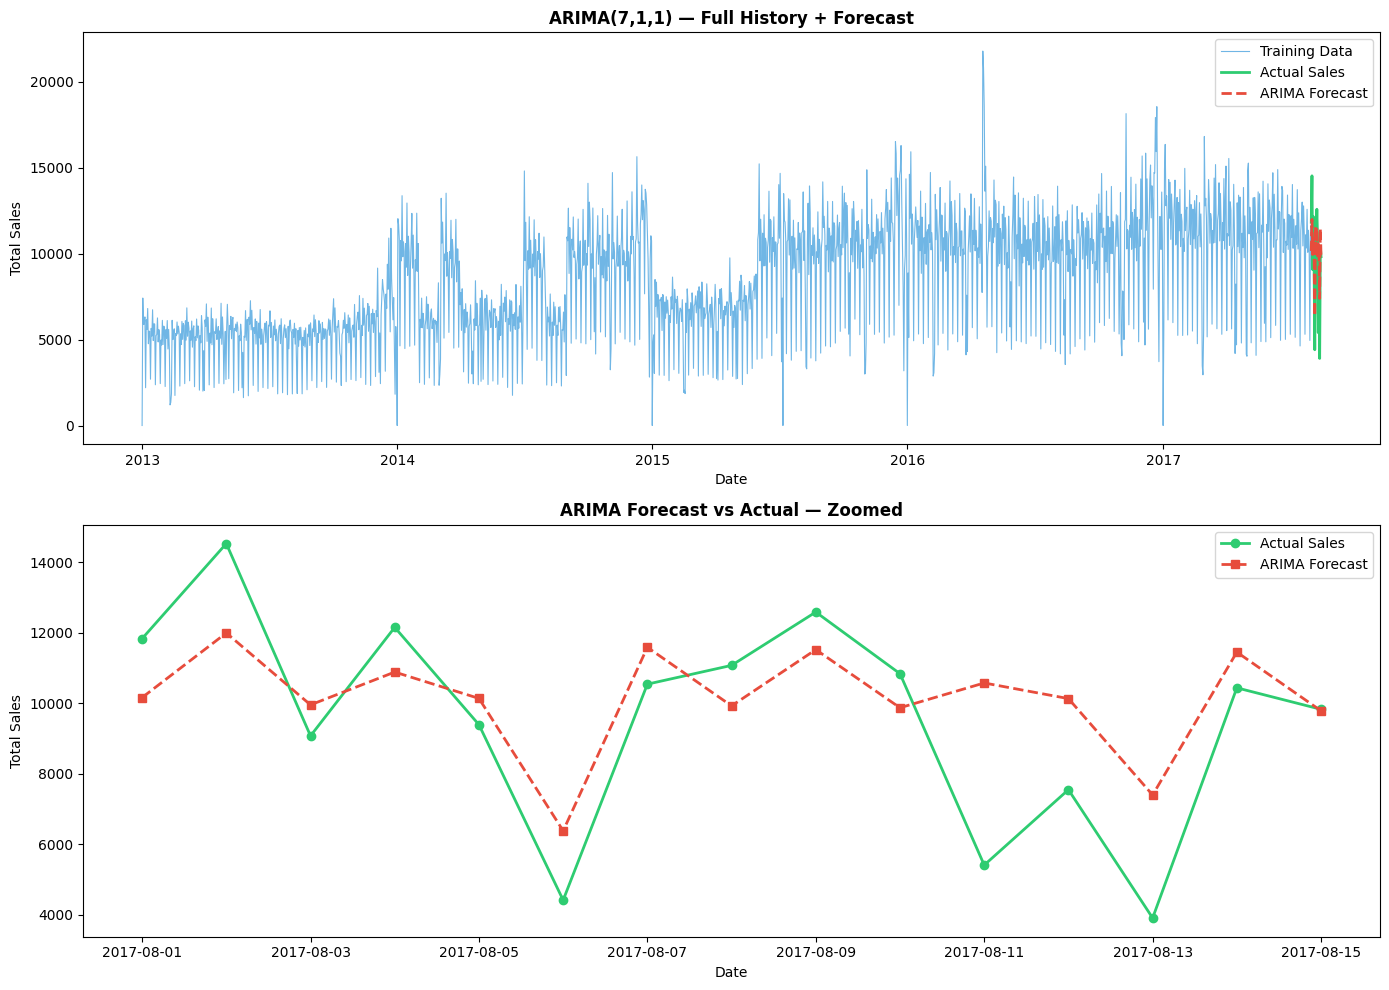


ARIMA Results Summary:
MAE:  1,706
RMSE: 2,115
MAPE: 24.8%


In [5]:
# Plot Forecast

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Full history + forecast
axes[0].plot(train.index, train['total_sales'],
             color='#3498db', linewidth=0.8,
             label='Training Data', alpha=0.7)
axes[0].plot(test.index, test['total_sales'],
             color='#2ecc71', linewidth=2,
             label='Actual Sales')
axes[0].plot(forecast_index, forecast.values,
             color='#e74c3c', linewidth=2,
             linestyle='--', label='ARIMA Forecast')
axes[0].set_title('ARIMA(7,1,1) — Full History + Forecast',
                  fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales')

# Plot 2 — Zoom into forecast period
axes[1].plot(test.index, test['total_sales'],
             color='#2ecc71', linewidth=2,
             marker='o', label='Actual Sales')
axes[1].plot(forecast_index, forecast.values,
             color='#e74c3c', linewidth=2,
             marker='s', linestyle='--',
             label='ARIMA Forecast')
axes[1].set_title('ARIMA Forecast vs Actual — Zoomed',
                  fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('../reports/figures/06_arima_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nARIMA Results Summary:')
print(f'MAE:  {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.1f}%')